In [1]:
#파이썬의 행렬과 관련된 수학식을 사용할 수 있는 라이브러리
import numpy as np

#데이터분석용 pandas 사용을 위한 라이브러리
import pandas as pd

#그래프 시각화를 위한 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm  #시각화 폰트

#문자데이터를 숫자로 인코딩 하기 위한 라이브러리
from sklearn.preprocessing import LabelEncoder

#전체 데이터를 학습용 데이터와 검증용 데이터로 나누기 위한 라이브러리
from sklearn.model_selection import train_test_split

#회귀 분석 평가 지표 사용을 위한 라이브러리
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
#폰트 확인

for f in fm.fontManager.ttflist:
  name = f.name
  if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Apple', 'Batang', 'Gulim']):
      print(name)

In [3]:
#나눔고딕 폰트로 그래프 폰트 변경(한글 깨짐 방지)
fm._load_fontmanager(try_read_cache=False)
plt.rc("font", family="NanumGothic")
plt.rc("axes", unicode_minus=False)

In [4]:
df = pd.read_csv('풍력.csv', encoding='cp949')
df

,시도명,설비용량(MW),발전일자,기온,강우량(mm),습도,적설량(mm),풍속,적운량(10분위),적운량(3분위),일조(hr),대기권밖일사량계산값,일사량,발전량(MWh),윤년여부
0,강원,295.334,2020-01-01 00:00,-3.0,NaN,24.0,NaN,4.3,0.0,1.0,NaN,0.0,NaN,0.01000,Y
1,강원,295.334,2020-01-01 01:00,-2.3,NaN,37.0,NaN,5.2,0.0,1.0,NaN,0.0,NaN,0.00000,Y
2,강원,295.334,2020-01-01 02:00,-1.6,NaN,38.0,NaN,3.9,0.0,1.0,NaN,0.0,NaN,0.00000,Y
3,강원,295.334,2020-01-01 03:00,-1.4,NaN,45.0,NaN,5.6,0.0,1.0,NaN,0.0,NaN,0.00000,Y
4,강원,295.334,2020-01-01 04:00,-0.9,NaN,46.0,NaN,5.1,0.0,1.0,NaN,0.0,NaN,0.00000,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806403,충북,416.000,2024-12-31 21:00,0.3,NaN,48.0,NaN,0.6,0.0,1.0,NaN,0.0,NaN,6.40000,Y
806404,충북,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45000,Y
806405,충북,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45081,Y
806406,충북,416.000,2024-12-31 23:00,-0.7,NaN,52.0,NaN,0.4,0.0,1.0,NaN,0.0,NaN,1.77408,Y


In [5]:
#상위 10개 데이터만 추출
sample_df = df.head(10)
sample_df

#샘플을 csv로 변환
sample_df.to_csv('sample_data.csv', index=False, encoding='cp949')

In [6]:
#결측치 유무 판단
df.isnull().sum()

시도명                0
설비용량(MW)           0
발전일자               0
기온               172
강우량(mm)       723553
습도               276
적설량(mm)       790155
풍속               903
적운량(10분위)        734
적운량(3분위)         734
일조(hr)        366427
대기권밖일사량계산값         0
일사량           366724
발전량(MWh)         527
윤년여부               0
dtype: int64

In [7]:
#각 열에 대한 식별자를 판단
len(df) #전체 데이터의 갯수
df.nunique()   #unique 고유한 값의 갯수 파악 => 전체 데이터의 갯수와 비슷하다? = 식별자

#df.nunique() / len(df) 로 유일값 비율 계산 → 1에 가까우면 식별자.
unique_rate = df.nunique() / len(df)
print(unique_rate.sort_values(ascending=False))

발전량(MWh)      0.284491
발전일자          0.054017
설비용량(MW)      0.000853
기온            0.000696
대기권밖일사량계산값    0.000578
강우량(mm)       0.000553
일사량           0.000489
적설량(mm)       0.000382
풍속            0.000212
습도            0.000201
시도명           0.000021
적운량(10분위)     0.000014
일조(hr)        0.000014
적운량(3분위)      0.000004
윤년여부          0.000002
dtype: float64


In [8]:
#상식적으로 풍력발전량 예측에 필요없는 컬럼 지우기
#df.drop(columns='시도명', inplace=True)  #첫 번째 방식
sido_delete_df = df.drop(columns='시도명') #두 번째 방식(*추천)
sido_delete_df

,설비용량(MW),발전일자,기온,강우량(mm),습도,적설량(mm),풍속,적운량(10분위),적운량(3분위),일조(hr),대기권밖일사량계산값,일사량,발전량(MWh),윤년여부
0,295.334,2020-01-01 00:00,-3.0,NaN,24.0,NaN,4.3,0.0,1.0,NaN,0.0,NaN,0.01000,Y
1,295.334,2020-01-01 01:00,-2.3,NaN,37.0,NaN,5.2,0.0,1.0,NaN,0.0,NaN,0.00000,Y
2,295.334,2020-01-01 02:00,-1.6,NaN,38.0,NaN,3.9,0.0,1.0,NaN,0.0,NaN,0.00000,Y
3,295.334,2020-01-01 03:00,-1.4,NaN,45.0,NaN,5.6,0.0,1.0,NaN,0.0,NaN,0.00000,Y
4,295.334,2020-01-01 04:00,-0.9,NaN,46.0,NaN,5.1,0.0,1.0,NaN,0.0,NaN,0.00000,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806403,416.000,2024-12-31 21:00,0.3,NaN,48.0,NaN,0.6,0.0,1.0,NaN,0.0,NaN,6.40000,Y
806404,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45000,Y
806405,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45081,Y
806406,416.000,2024-12-31 23:00,-0.7,NaN,52.0,NaN,0.4,0.0,1.0,NaN,0.0,NaN,1.77408,Y


In [9]:
#컬럼별 결측치 비율
#na_rate = sido_delete_df.isnull().sum() / len(sido_delete_df)
#na_rate

#강우량(mm), 적설량(mm), 일조(hr), 일사량, 윤년여부 컬럼 삭제
all_delete_df = df.drop(columns=['강우량(mm)', '적설량(mm)', '일조(hr)', '일사량', '윤년여부'])
all_delete_df

,시도명,설비용량(MW),발전일자,기온,습도,풍속,적운량(10분위),적운량(3분위),대기권밖일사량계산값,발전량(MWh)
0,강원,295.334,2020-01-01 00:00,-3.0,24.0,4.3,0.0,1.0,0.0,0.01000
1,강원,295.334,2020-01-01 01:00,-2.3,37.0,5.2,0.0,1.0,0.0,0.00000
2,강원,295.334,2020-01-01 02:00,-1.6,38.0,3.9,0.0,1.0,0.0,0.00000
3,강원,295.334,2020-01-01 03:00,-1.4,45.0,5.6,0.0,1.0,0.0,0.00000
4,강원,295.334,2020-01-01 04:00,-0.9,46.0,5.1,0.0,1.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...
806403,충북,416.000,2024-12-31 21:00,0.3,48.0,0.6,0.0,1.0,0.0,6.40000
806404,충북,416.000,2024-12-31 22:00,-0.2,51.0,0.3,0.0,1.0,0.0,3.45000
806405,충북,416.000,2024-12-31 22:00,-0.2,51.0,0.3,0.0,1.0,0.0,3.45081
806406,충북,416.000,2024-12-31 23:00,-0.7,52.0,0.4,0.0,1.0,0.0,1.77408


In [ ]:
#시각화(차트)를 위한 라이브러리 설치
!pip install matplotlib seaborn

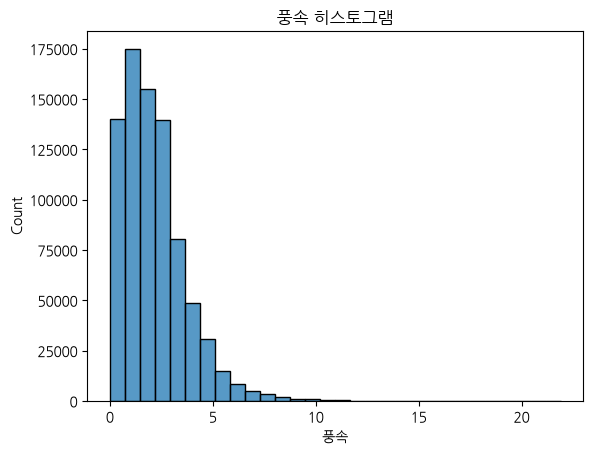

In [11]:
#히스토그램으로 풍속 데이터의 분포를 확인
sns.histplot(all_delete_df['풍속'], bins=30)
plt.title('풍속 히스토그램')
plt.show()

In [12]:
#정규분포를 따르지 않기 때문에 이상치 판단은 IQR 방식
# 1Q(1 사분면 구함)
Q1 = all_delete_df['풍속'].quantile(0.25) #1.0
Q1

Q3 = all_delete_df['풍속'].quantile(0.75) #2.9
print(Q3)

IQR = Q3 - Q1
lower = Q1 - (1.5 * IQR) #-1.85
print(lower)
upper = Q3 + (1.5 * IQR) #5.75
print(upper)

2.9
-1.8499999999999996
5.75


In [13]:
#결측치 확인
#모델에 따라 결측치의 처리 여부가 바뀐다(결측치 상관 없을 수 있을...? 혹은 결측치를 채워줘야하는 경우/ 결측치 삭제 해야하는 모델이 있담)

na_rate = all_delete_df.isnull().sum() / len(all_delete_df)
na_rate

시도명           0.000000
설비용량(MW)      0.000000
발전일자          0.000000
기온            0.000213
습도            0.000342
풍속            0.001120
적운량(10분위)     0.000910
적운량(3분위)      0.000910
대기권밖일사량계산값    0.000000
발전량(MWh)      0.000654
dtype: float64

In [14]:
#결측치 제거 전 데이터 수
len(all_delete_df) #806408

#결측치가 모두 5% 이하여서 결측치가 있는 데이터 삭제
final_df = all_delete_df.dropna()

len(final_df) #804009
final_df.isnull().sum()

시도명           0
설비용량(MW)      0
발전일자          0
기온            0
습도            0
풍속            0
적운량(10분위)     0
적운량(3분위)      0
대기권밖일사량계산값    0
발전량(MWh)      0
dtype: int64

In [15]:
#범주형 데이터(시도) 인코딩
#고유한 값의 갯수
final_df.nunique()   #시도 : 17개


시도명               17
설비용량(MW)         688
발전일자           43515
기온               561
습도               162
풍속               171
적운량(10분위)         11
적운량(3분위)           3
대기권밖일사량계산값       466
발전량(MWh)      228952
dtype: int64

In [ ]:
#학습 진행을 위해 우선 sklearn 라이브러리 설치 (싸이킷런)
!pip install scikit-learn

In [17]:
#학습데이터와 검증데이터로 분리(test_size=20%/random_state=42(팀끼리는 random은 통일 7 or 42))
train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42)

In [18]:
#학습데이터의 시도 데이터를 인코딩
le = LabelEncoder()

#인코딩 진행
#fit() : 데이터를 파악하고, 어떤 숫자로 매칭할 지 결정까지만!  = 노 반영!
le.fit(train_df['시도명'])

#인코딩하고 다시 실행을하면 인코딩이 다시 시작된다 -> 인코딩 된 파일 자체로 가지고 있어야 한다.

#fit()함수의 결과로 결정된 인코딩 방식
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'강원': np.int64(0), '경기': np.int64(1), '경남': np.int64(2), '경북': np.int64(3), '광주': np.int64(4), '대구': np.int64(5), '대전': np.int64(6), '부산': np.int64(7), '서울': np.int64(8), '세종': np.int64(9), '울산': np.int64(10), '인천': np.int64(11), '전남': np.int64(12), '전북': np.int64(13), '제주': np.int64(14), '충남': np.int64(15), '충북': np.int64(16)}


In [19]:
#위에서 정한 인코딩 방식을 다음에 사용 시 동일하게 사용할 수 있도록 le객체(인코딩 알고리즘을 가지고 있는)를 파일로 저장
import pickle

#'le_시도명.pkl' : 만들어진 파일명.pkl, 
# 'wb'(write, binary) : 2진 데이터 파일로 만들어주세요.   이 파일을 f로 부르겠다.
with open('le_시도명.pkl', 'wb') as f : 
  pickle.dump(le, f)

In [20]:
#파일로 만든 객체 불러오기
load_le = None
with open('le_시도명.pkl', 'rb') as f :
  load_le = pickle.load(f) 

#위에서 불러왔으면
#load_le.transform()

In [21]:
#train_df.drop(columns='encoded_시도명', inplace=True)
#train_df

#transform() : fit()함수의 실행으로 결정된 인코딩 방식을 실제로 적용하는 함수 / fit -> fransfrom -> fit  =>매칭을 결정하고 적용했는데 다시 매칭한다는건 xx
train_df['encoded_시도명'] = le.transform(train_df['시도명'])
train_df

test_df['encoded_시도명'] = le.transform(test_df['시도명'])
test_df

,시도명,설비용량(MW),발전일자,기온,습도,풍속,적운량(10분위),적운량(3분위),대기권밖일사량계산값,발전량(MWh),encoded_시도명
38673,강원,720.000,2024-04-17 04:00,14.4,57.0,3.1,0.0,1.0,0.00,0.17000,0
399405,세종,24.594,2022-02-20 13:00,-1.7,21.0,5.5,0.0,1.0,3.34,16.97000,9
498017,경북,636.072,2022-07-12 09:00,25.6,70.0,2.6,7.0,2.0,3.22,182.10000,3
457018,경기,327.478,2023-04-13 02:00,5.5,74.0,1.7,0.0,1.0,0.00,0.00000,1
131809,대구,62.000,2024-02-12 20:00,5.8,43.0,1.4,0.0,1.0,0.00,0.80011,5
...,...,...,...,...,...,...,...,...,...,...,...
252586,부산,72.100,2021-09-05 02:00,21.5,75.0,3.0,9.0,3.0,0.00,0.00000,7
262631,부산,87.399,2022-10-28 15:00,21.8,61.0,2.7,3.0,1.0,2.51,16.41000,7
300459,충남,702.082,2021-09-17 19:00,21.4,78.0,0.9,3.0,1.0,0.00,112.63000,15
65755,광주,59.336,2022-01-27 11:00,4.0,41.0,1.7,7.0,2.0,2.68,28.67000,4


In [22]:
test_df

,시도명,설비용량(MW),발전일자,기온,습도,풍속,적운량(10분위),적운량(3분위),대기권밖일사량계산값,발전량(MWh),encoded_시도명
38673,강원,720.000,2024-04-17 04:00,14.4,57.0,3.1,0.0,1.0,0.00,0.17000,0
399405,세종,24.594,2022-02-20 13:00,-1.7,21.0,5.5,0.0,1.0,3.34,16.97000,9
498017,경북,636.072,2022-07-12 09:00,25.6,70.0,2.6,7.0,2.0,3.22,182.10000,3
457018,경기,327.478,2023-04-13 02:00,5.5,74.0,1.7,0.0,1.0,0.00,0.00000,1
131809,대구,62.000,2024-02-12 20:00,5.8,43.0,1.4,0.0,1.0,0.00,0.80011,5
...,...,...,...,...,...,...,...,...,...,...,...
252586,부산,72.100,2021-09-05 02:00,21.5,75.0,3.0,9.0,3.0,0.00,0.00000,7
262631,부산,87.399,2022-10-28 15:00,21.8,61.0,2.7,3.0,1.0,2.51,16.41000,7
300459,충남,702.082,2021-09-17 19:00,21.4,78.0,0.9,3.0,1.0,0.00,112.63000,15
65755,광주,59.336,2022-01-27 11:00,4.0,41.0,1.7,7.0,2.0,2.68,28.67000,4


In [23]:
#학습 데이터 정리

train_col = ['설비용량(MW)',	
  '기온',	
  '습도',	
  '풍속',	
  'encoded_시도명']

#학습데이터:독립변수 (train_df의 발전량을 제외한 데이터)
X_train = train_df[train_col]

#학습에 대한 답 데이터:종속 (train_df의 발전량)
y_train = train_df['발전량(MWh)']

#검증용 데이터
X_test = test_df[train_col]
y_test = test_df['발전량(MWh)']

In [24]:
#randomforest
from sklearn.ensemble import RandomForestRegressor

#랜덤포레스트 객체 생성
rf_model = RandomForestRegressor(
  n_estimators=100,  #트리를 몇개 만들지 지정
  random_state=42,
  n_jobs=-1
)

#모델 학습
rf_model.fit(X_train, y_train)

#예측
rf_pridict = rf_model.predict(X_test)

In [25]:
!pip install xgboost

In [26]:
#XGboost
from xgboost import XGBRegressor

#학습할 객체 생성
xg_model = XGBRegressor(
  n_estimators=100,
  learning_rate=0.1,
  random_state=42,
  n_jobs=-1
)

#학습
xg_model.fit(X_train, y_train)

#예측
xg_pridict = xg_model.predict(X_test)

In [27]:
#예측 결과에 대한 지표 확인
#MAE : 예측값과 실제값 차이의 절대값 평균 => 평균적인 오차를 나타내기 때문에 작을수록 좋음.
#RMSE : 예측값과 실제값의 차이를 제곱한 뒤 평균을 내고 다시 제곱근을 씌운 값 => 작을수록 좋다.
#R2 : 0~1사이, 1에 가까울수록 좋음 => 모델의 데이터 변동을 설명하는 값

#randomfrest 결과 분석 (정답지, 예측결과지)
rf_mae = mean_absolute_error(y_test, rf_pridict)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pridict))
rf_r2 = r2_score(y_test, rf_pridict)

print(f'랜덤포레스트 MAE = {rf_mae}, RMSE = {rf_rmse}, R2 = {rf_r2}')

#xgboot 결과 분석
xg_mae = mean_absolute_error(y_test, xg_pridict)
xg_rmse = np.sqrt(mean_squared_error(y_test, xg_pridict))
xg_r2 = r2_score(y_test, xg_pridict)

print(f'xgboot MAE = {xg_mae}, RMSE = {xg_rmse}, R2 = {xg_r2}')


랜덤포레스트 MAE = 33.59518447201706, RMSE = 75.44366493629059, R2 = 0.7214948065263834
xgboot MAE = 39.40496227797082, RMSE = 84.26188044309261, R2 = 0.6525838231504094


In [31]:
importance = pd.DataFrame({
  'feature' : train_col,
  'rf_impotance' : rf_model.feature_importances_,
  'xgb_importance' : xg_model.feature_importances_
}).sort_values('xgb_importance', ascending=False)

print(importance) # 1에 가까울수록 발전량에 더 많은 영향을 미치는 변수

       feature  rf_impotance  xgb_importance
0     설비용량(MW)      0.426938        0.485778
2           습도      0.235082        0.285216
1           기온      0.213997        0.156695
4  encoded_시도명      0.011812        0.037338
3           풍속      0.112171        0.034973
